# Loan Default Prediction — Full Pipeline

This notebook walks through a complete supervised-learning pipeline on the loan default dataset:
load → clean → feature engineering → join → EDA → model training → submission → scoring.
All cells execute top-to-bottom with no manual re-ordering required.

In [44]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    roc_auc_score, f1_score,
)

try:
    from xgboost import XGBClassifier, XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed — XGBoost models will be skipped")

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

xgboost not installed — XGBoost models will be skipped


## 1. Load

Read all five source files. `train.csv` provides labelled loan IDs; `eval.csv` lists the
loans we must predict. The answer key is held out for final scoring only.

In [45]:
DATA_DIR = os.getcwd()

borrowers       = pd.read_csv(os.path.join(DATA_DIR, "borrowers.csv"))
loans           = pd.read_csv(os.path.join(DATA_DIR, "loans.csv"))
payment_history = pd.read_csv(os.path.join(DATA_DIR, "payment_history.csv"))
train_labels    = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
eval_ids        = pd.read_csv(os.path.join(DATA_DIR, "eval.csv"))
answer_key      = pd.read_csv(os.path.join(DATA_DIR, "answer_key.csv"))

print(f"Borrowers:       {borrowers.shape}")
print(f"Loans:           {loans.shape}")
print(f"Payment history: {payment_history.shape}")
print(f"Train labels:    {train_labels.shape}")
print(f"Eval IDs:        {eval_ids.shape}")
print(f"\nDefault rate (train): {train_labels['default_flag'].mean():.1%}")

Borrowers:       (71681, 10)
Loans:           (181800, 9)
Payment history: (627511, 6)
Train labels:    (125999, 3)
Eval IDs:        (54001, 1)

Default rate (train): 17.9%


## 2. Quick EDA — Raw Data Quality

Before touching the data, verify null rates and identify structural issues (orphan IDs,
duplicate keys). This guides what cleaning is actually needed.

In [46]:
print("=== Null counts ===")
for name, frame in [
    ("borrowers", borrowers), ("loans", loans),
    ("payment_history", payment_history), ("train_labels", train_labels),
]:
    nulls = frame.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls):
        print(f"\n{name}:")
        print(nulls.to_string())
    else:
        print(f"\n{name}: no nulls")

# Orphan check
orphan_loans = loans[~loans["borrower_id"].isin(borrowers["borrower_id"])]
print(f"\nLoans with orphan borrower_id: {len(orphan_loans):,} ({len(orphan_loans)/len(loans):.1%})")

train_not_in_loans = train_labels[~train_labels["loan_id"].isin(loans["loan_id"])]
print(f"Train loan_ids missing from loans table: {len(train_not_in_loans):,}")

=== Null counts ===

borrowers:
credit_score                 651
annual_income                683
debt_to_income_ratio         607
employment_years             600
num_existing_loans           619
previous_defaults            635
months_since_last_inquiry    629
city                         638
state                        633

loans:
principal                  1509
interest_rate              1542
term_months                1588
loan_type                  1532
monthly_payment            1524
payment_to_income_ratio    1600
origination_date           1514

payment_history:
payment_due_date    15537
amount_due          15480
amount_paid         15578
days_delinquent     15390

train_labels: no nulls

Loans with orphan borrower_id: 740 (0.4%)
Train loan_ids missing from loans table: 0


In [47]:
# Representative sample of each raw table
print("--- borrowers.head() ---")
display(borrowers.head())
print("--- loans.head() ---")
display(loans.head())
print("--- payment_history.head() ---")
display(payment_history.head())

--- borrowers.head() ---


,borrower_id,credit_score,annual_income,debt_to_income_ratio,employment_years,num_existing_loans,previous_defaults,months_since_last_inquiry,city,state
0,BR18027-300472,692.0,127642.54,35.8,19.0,3.0,2.0,21.0,New Steven,ND
1,BR23012-973179,679.0,202524.72,41.9,11.0,5.0,1.0,31.0,Lake Jeremyfort,WA
2,BR16070-575107,609.0,129534.48,34.8,23.0,4.0,2.0,21.0,Daltonton,NY
3,BR34869-256956,540.0,100154.41,35.2,28.0,4.0,2.0,28.0,South Andrea,CO
4,BR36175-845320,580.0,113578.86,35.1,10.0,5.0,2.0,17.0,South Lisa,ND


--- loans.head() ---


,loan_id,borrower_id,principal,interest_rate,term_months,loan_type,monthly_payment,payment_to_income_ratio,origination_date
0,L5602-257106,BR35493-663977,94534.34,12.25,55.0,credit_line,2254.77,0.179,2023-01-01
1,L55230-524049,BR98245-39487,90198.76,12.29,41.0,home_equity,2705.18,0.113,2023-09-14
2,L65349-518404,BR22077-606946,65271.15,20.43,43.0,home_equity,2153.08,0.161,2023-02-01
3,L40551-771618,BR82403-197452,84142.69,18.37,35.0,credit_line,3123.28,0.078,2023-09-16
4,L83605-815564,BR82771-101736,NaN,16.31,32.0,home_equity,3771.94,0.245,2023-07-16


--- payment_history.head() ---


,loan_id,month_number,payment_due_date,amount_due,amount_paid,days_delinquent
0,L77639-244888,1,2023-01-15,2568.39,2073.50,0.0
1,L77639-244888,2,2023-02-15,2568.39,2586.16,0.0
2,L77639-244888,3,2023-03-15,2568.39,2138.35,0.0
3,L76536-178626,1,2023-01-15,2468.57,2219.55,0.0
4,L76536-178626,2,2023-02-15,2468.57,2217.15,0.0


## 3. Clean

Standardise string columns, drop duplicate primary keys, and restrict payment history to
known loans (preventing a left-join explosion from stale records).

In [48]:
def clean_str(s):
    return str(s).strip().lower() if pd.notna(s) else s

borrowers["state"]    = borrowers["state"].apply(clean_str)
loans["loan_type"]    = loans["loan_type"].apply(clean_str)

# Keep only payment records that belong to a known loan
payment_history = payment_history[payment_history["loan_id"].isin(loans["loan_id"])]

borrowers       = borrowers.drop_duplicates(subset=["borrower_id"], keep="first")
loans           = loans.drop_duplicates(subset=["loan_id"],     keep="first")
payment_history = payment_history.drop_duplicates(subset=["loan_id", "month_number"], keep="first")

print(f"Cleaned borrowers:       {len(borrowers):,}")
print(f"Cleaned loans:           {len(loans):,}")
print(f"Cleaned payment records: {len(payment_history):,}")

Cleaned borrowers:       70,972
Cleaned loans:           180,000
Cleaned payment records: 627,511


## 4. Feature Engineering — Payment History Aggregation

Raw payment records are at monthly granularity. We aggregate them to the loan level to
create behavioural features: on-time rate and cumulative delinquent days. These capture
actual repayment behaviour rather than static borrower attributes.

Note: `delinquent_rate = 1 − on_time_rate` by construction (r = −1.0), so it is
redundant and will be excluded from model features.

In [49]:
ph_agg = payment_history.groupby("loan_id").agg(
    on_time_count        =("days_delinquent", lambda x: (x.fillna(999) == 0).sum()),
    total_days_delinquent=("days_delinquent", lambda x: x.fillna(0).sum()),
    n_months             =("month_number",    "count"),
).reset_index()

ph_agg["on_time_rate"] = ph_agg["on_time_count"] / ph_agg["n_months"].replace(0, np.nan)
# delinquent_rate omitted — perfectly collinear with on_time_rate

print(f"Payment aggregation: {ph_agg.shape}")
display(ph_agg.head())

Payment aggregation: (180000, 5)


,loan_id,on_time_count,total_days_delinquent,n_months,on_time_rate
0,L100-29525,2,0.0,3,0.666667
1,L100-526649,5,0.0,5,1.000000
2,L100-874457,2,0.0,2,1.000000
3,L1000-338823,1,0.0,2,0.500000
4,L1000-533418,3,0.0,4,0.750000


## 5. Join Everything

Merge loans ← borrowers ← payment aggregates. After joining we apply two data-quality
steps before creating any model inputs:

1. **Outlier clipping** — monetary and score fields should not be negative; clip to zero.
2. **Missing value imputation** — loans with no payment history get a `has_payment_history=0`
   flag, and payment features are filled with the observed median (more informative than a
   hard-coded 1.0/0). Borrower numeric fields are also median-imputed.

In [50]:
df = loans.merge(
    borrowers[[
        "borrower_id", "credit_score", "annual_income", "employment_years",
        "debt_to_income_ratio", "num_existing_loans", "previous_defaults",
        "months_since_last_inquiry", "state",
    ]],
    on="borrower_id", how="left",
)
df = df.merge(ph_agg, on="loan_id", how="left")

# ── Encode categoricals ────────────────────────────────────────────────────
for col in ["loan_type", "state"]:
    df[col] = df[col].fillna("unknown")
    le = LabelEncoder()
    df[f"{col}_enc"] = le.fit_transform(df[col].astype(str))

# ── P1.1: Outlier clipping — these fields must be non-negative ─────────────
# Negative credit scores, incomes, or payment amounts are data errors.
clip_cols = ["credit_score", "annual_income", "principal", "monthly_payment"]
for col in clip_cols:
    df[col] = df[col].clip(lower=0)

# ── P1.2: NaN imputation ──────────────────────────────────────────────────
# Flag: did this loan appear in payment_history at all?
df["has_payment_history"] = df["on_time_rate"].notna().astype(int)

# Compute medians only from loans that have payment history
pmt_median_on_time = df.loc[df["has_payment_history"] == 1, "on_time_rate"].median()
pmt_median_days    = df.loc[df["has_payment_history"] == 1, "total_days_delinquent"].median()

df["on_time_rate"]          = df["on_time_rate"].fillna(pmt_median_on_time)
df["total_days_delinquent"] = df["total_days_delinquent"].fillna(pmt_median_days)
df["n_months"]              = df["n_months"].fillna(0)

# Median-impute borrower numeric features (handles orphan/missing borrowers)
borrower_num_cols = [
    "credit_score", "annual_income", "employment_years",
    "debt_to_income_ratio", "num_existing_loans",
    "previous_defaults", "months_since_last_inquiry",
]
for col in borrower_num_cols:
    df[col] = df[col].fillna(df[col].median())

# Median-impute loan-level numeric features (~0.8% nulls from source table)
loan_num_cols = ["principal", "interest_rate", "term_months",
                 "monthly_payment", "payment_to_income_ratio"]
for col in loan_num_cols:
    df[col] = df[col].fillna(df[col].median())

print(f"Joined dataset: {df.shape}")
print(f"Loans with payment history: {df['has_payment_history'].mean():.1%}")
remaining = df[borrower_num_cols + loan_num_cols + ["on_time_rate", "total_days_delinquent"]].isnull().sum().sum()
print(f"Remaining nulls in feature columns: {remaining}")

Joined dataset: (180000, 24)
Loans with payment history: 100.0%
Remaining nulls in feature columns: 0


## 6. Prepare Train / Eval Sets

Define the feature matrix, split off a held-out validation set (20 %, stratified on
`default_flag`), and build the eval set for submission predictions.

`delinquent_rate` is excluded — it is perfectly collinear with `on_time_rate` (r = −1.0)
and would add zero information while inflating the feature count.

In [51]:
# ── P1.3: delinquent_rate removed (r = -1.0 with on_time_rate) ────────────
feature_cols = [
    "principal", "interest_rate", "term_months", "monthly_payment",
    "payment_to_income_ratio", "credit_score", "annual_income",
    "employment_years", "debt_to_income_ratio", "num_existing_loans",
    "previous_defaults", "months_since_last_inquiry",
    "loan_type_enc", "state_enc",
    "on_time_rate", "total_days_delinquent", "has_payment_history",
]

train_df = df.merge(train_labels, on="loan_id", how="inner")
eval_df  = df.merge(eval_ids,    on="loan_id", how="inner")

X_train    = train_df[feature_cols].replace([np.inf, -np.inf], 0)
y_train_reg = train_df["days_to_early_default"]
y_train_cls = train_df["default_flag"]
X_eval     = eval_df[feature_cols].replace([np.inf, -np.inf], 0)

# ── P1.4: Train / Validation Split ────────────────────────────────────────
# stratify=y_train_cls keeps the same default rate in both splits
X_tr, X_val, y_tr_reg, y_val_reg, y_tr_cls, y_val_cls = train_test_split(
    X_train, y_train_reg, y_train_cls,
    test_size=0.2, random_state=42, stratify=y_train_cls,
)

print(f"X_train  : {X_train.shape}   default rate: {y_train_cls.mean():.2%}")
print(f"X_tr     : {X_tr.shape}   default rate: {y_tr_cls.mean():.2%}")
print(f"X_val    : {X_val.shape}   default rate: {y_val_cls.mean():.2%}")
print(f"X_eval   : {X_eval.shape}")

X_train  : (125999, 17)   default rate: 17.95%
X_tr     : (100799, 17)   default rate: 17.95%
X_val    : (25200, 17)   default rate: 17.95%
X_eval   : (54001, 17)


## 7. Exploratory Data Analysis

With `train_df` in hand we can explore the target distribution, feature distributions,
and how each feature differs between defaulters and non-defaulters.

Default counts:
default_flag
0    103386
1     22613
Name: count, dtype: int64

Overall default rate: 17.95%


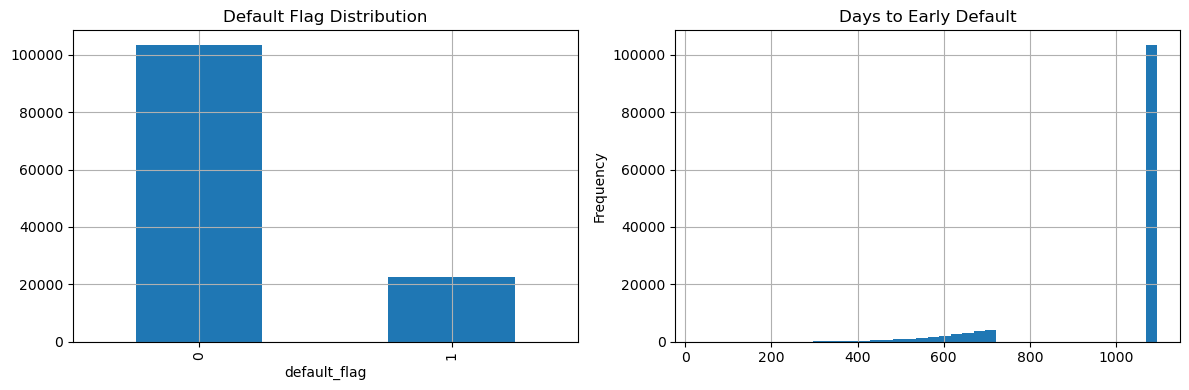

In [52]:
# Target distribution
default_counts = train_df["default_flag"].value_counts().sort_index()
default_rate   = train_df["default_flag"].mean()

print(f"Default counts:\n{default_counts}")
print(f"\nOverall default rate: {default_rate:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
default_counts.plot(kind="bar", ax=axes[0], title="Default Flag Distribution")
train_df["days_to_early_default"].plot(kind="hist", bins=40, ax=axes[1],
    title="Days to Early Default")
plt.tight_layout()
plt.show()

Days to Early Default — grouped by default_flag:
                 count    mean   std     min     25%     50%     75%     max
default_flag                                                                
0             103386.0  1095.0   0.0  1095.0  1095.0  1095.0  1095.0  1095.0
1              22613.0   615.7  89.4    30.0   570.0   638.0   685.0   720.0


<Figure size 800x500 with 0 Axes>

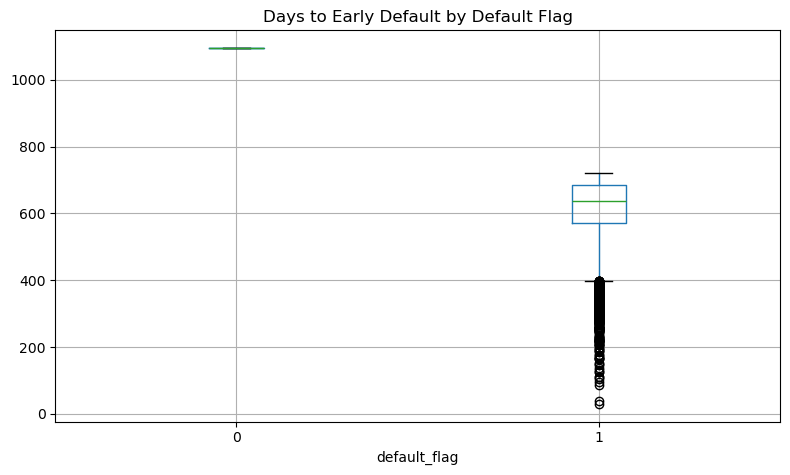

In [53]:
# Days to early default by default flag
group_summary = train_df.groupby("default_flag")["days_to_early_default"].describe()
print("Days to Early Default — grouped by default_flag:")
print(group_summary.round(1))

plt.figure()
train_df.boxplot(column="days_to_early_default", by="default_flag")
plt.title("Days to Early Default by Default Flag")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [54]:
# Summary statistics for numerical features
num_cols_eda = [
    "credit_score", "annual_income", "debt_to_income_ratio",
    "principal", "interest_rate", "monthly_payment",
    "payment_to_income_ratio", "employment_years",
    "num_existing_loans", "previous_defaults",
    "months_since_last_inquiry", "on_time_rate", "total_days_delinquent",
]

summary_stats = train_df[num_cols_eda].describe().T
summary_stats["missing_count"] = train_df[num_cols_eda].isna().sum()
summary_stats["missing_rate"]  = train_df[num_cols_eda].isna().mean()
print(summary_stats[["count","mean","std","min","50%","max","missing_rate"]].round(3).to_string())

                              count        mean        std     min         50%         max  missing_rate
credit_score               125999.0     595.783     77.428   0.000     595.000    1234.890           0.0
annual_income              125999.0  138786.653  29434.541   0.000  138495.190  395181.739           0.0
debt_to_income_ratio       125999.0      35.145      6.480 -19.052      35.100      89.376           0.0
principal                  125999.0   82337.399  18333.837   0.000   82197.700  242229.390           0.0
interest_rate              125999.0      16.637      3.218  -9.512      16.650      42.797           0.0
monthly_payment            125999.0    2441.510    664.389   0.000    2390.910    8338.845           0.0
payment_to_income_ratio    125999.0       0.183      0.046  -0.194       0.183       0.560           0.0
employment_years           125999.0      16.697      4.801 -22.473      17.000      55.878           0.0
num_existing_loans         125999.0       4.233      1.

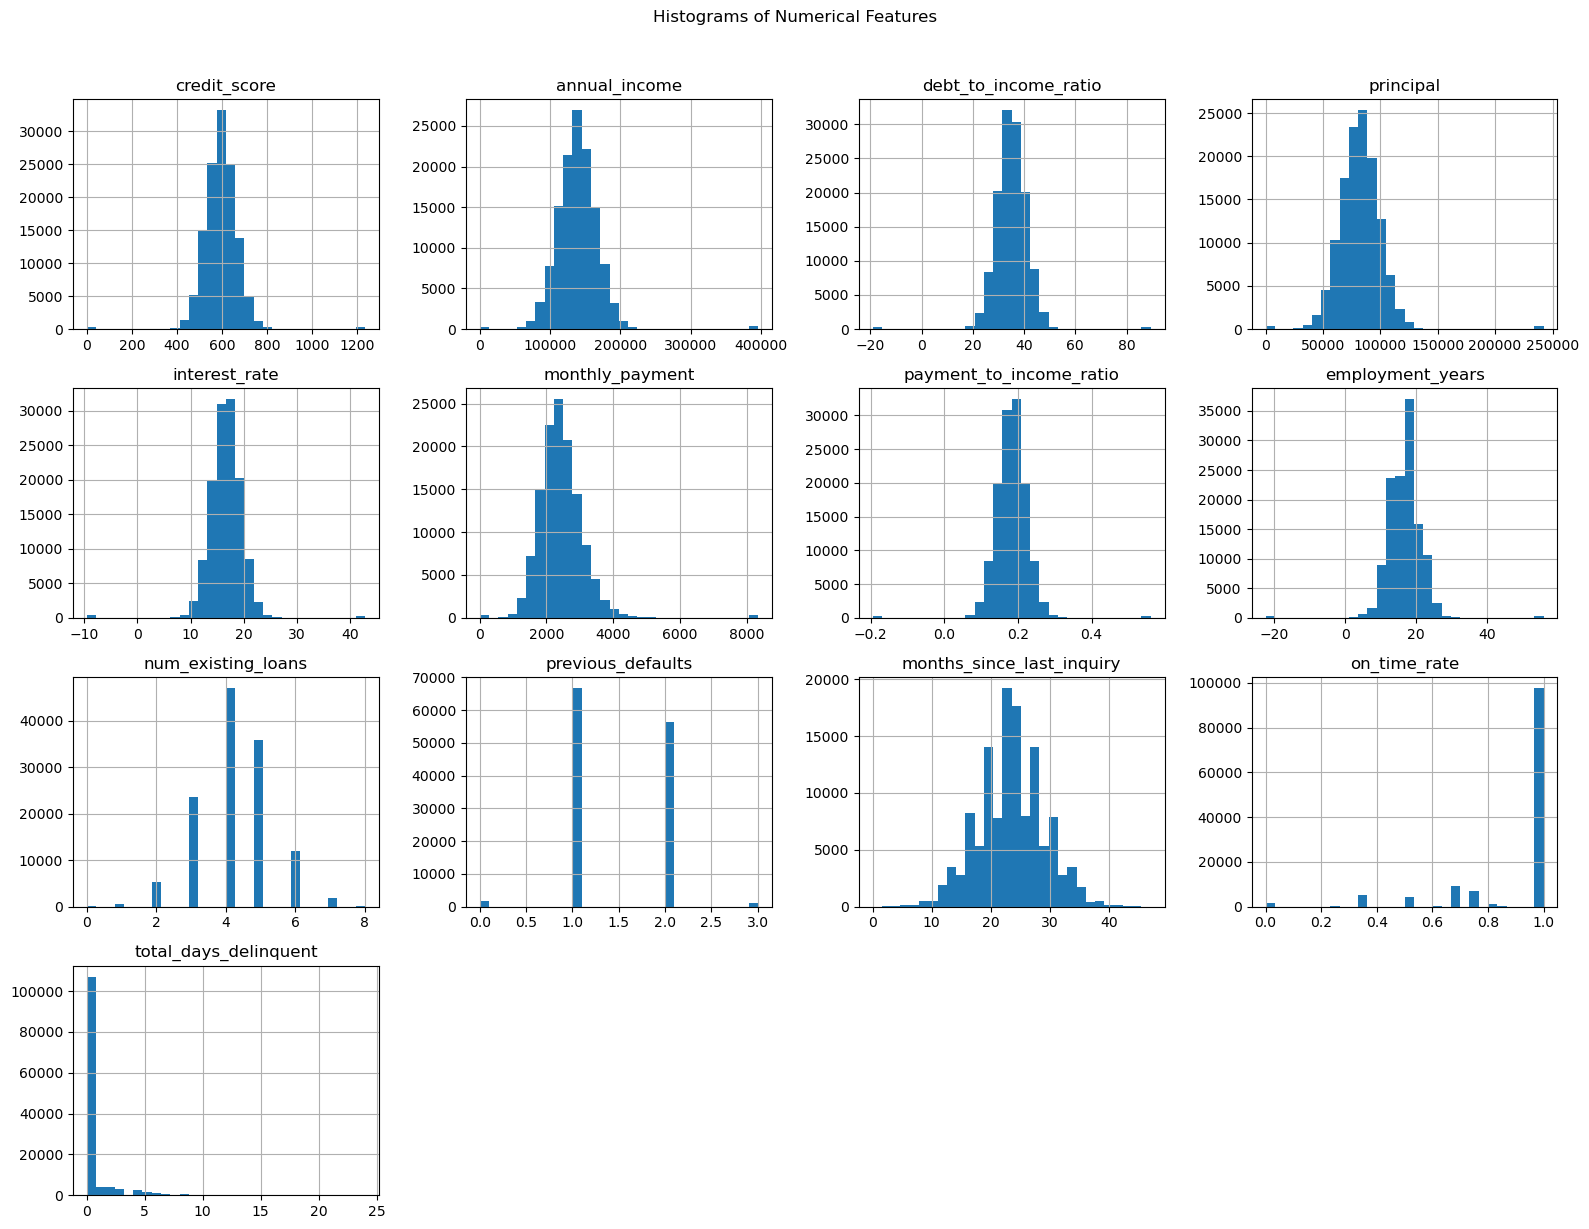

In [55]:
# Feature histograms
train_df[num_cols_eda].hist(bins=30, figsize=(16, 12))
plt.suptitle("Histograms of Numerical Features", y=1.02)
plt.tight_layout()
plt.show()

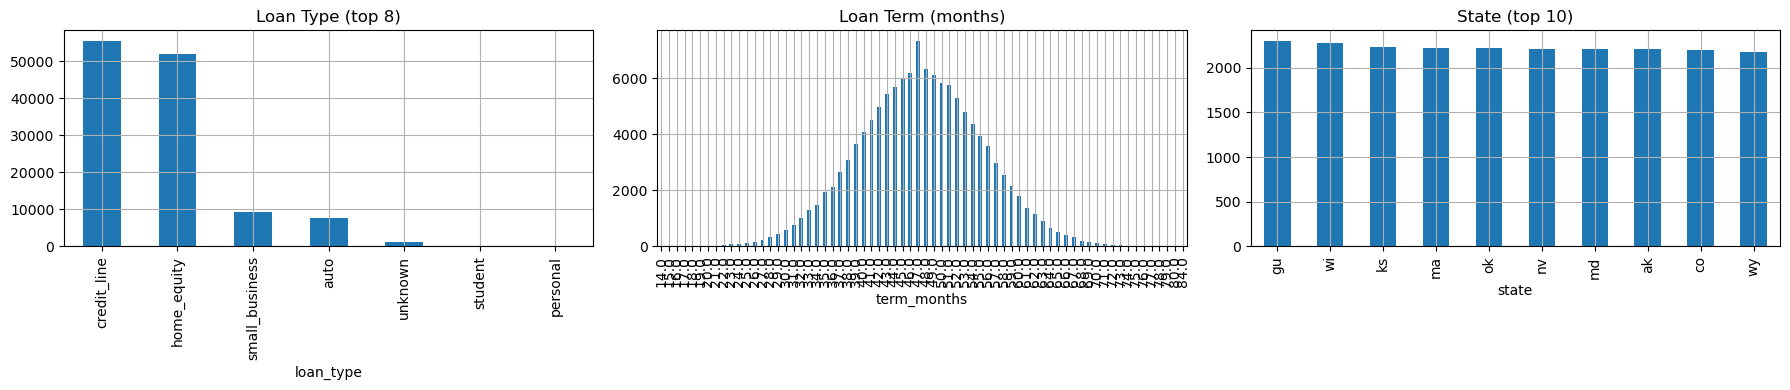

In [56]:
# Categorical distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

loan_type_counts = train_df["loan_type"].fillna("unknown").value_counts()
loan_type_counts.head(8).plot(kind="bar", ax=axes[0], title="Loan Type (top 8)")

term_counts = train_df["term_months"].value_counts().sort_index()
term_counts.plot(kind="bar", ax=axes[1], title="Loan Term (months)")

state_counts = train_df["state"].fillna("unknown").value_counts()
state_counts.head(10).plot(kind="bar", ax=axes[2], title="State (top 10)")

plt.tight_layout()
plt.show()

In [57]:
# Mean comparison: defaulters vs non-defaulters
compare_cols = [
    "credit_score", "annual_income", "debt_to_income_ratio",
    "principal", "interest_rate", "payment_to_income_ratio",
    "employment_years", "num_existing_loans", "previous_defaults",
    "months_since_last_inquiry", "on_time_rate", "total_days_delinquent",
]
group_means = train_df.groupby("default_flag")[compare_cols].mean().T
group_means.columns = ["Non-Default (0)", "Default (1)"]
group_means["Difference"]  = group_means["Default (1)"] - group_means["Non-Default (0)"]
group_means["Ratio (1/0)"] = group_means["Default (1)"] / group_means["Non-Default (0)"].replace(0, np.nan)
print(group_means.round(3).to_string())

                           Non-Default (0)  Default (1)  Difference  Ratio (1/0)
credit_score                       595.751      595.927       0.176        1.000
annual_income                   138844.047   138524.249    -319.797        0.998
debt_to_income_ratio                35.134       35.197       0.063        1.002
principal                        84134.607    74120.613  -10013.994        0.881
interest_rate                       16.637       16.637      -0.001        1.000
payment_to_income_ratio              0.184        0.177      -0.008        0.958
employment_years                    16.736       16.521      -0.215        0.987
num_existing_loans                   4.270        4.066      -0.204        0.952
previous_defaults                    1.448        1.459       0.011        1.007
months_since_last_inquiry           23.495       23.197      -0.298        0.987
on_time_rate                         0.976        0.571      -0.405        0.585
total_days_delinquent       

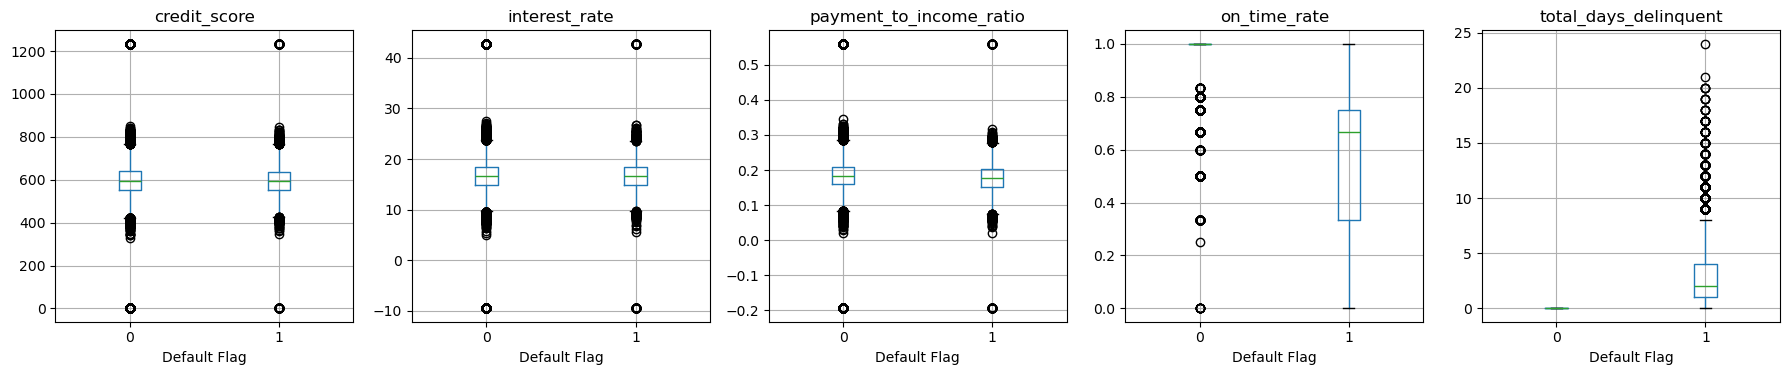

In [58]:
# Box plots for key discriminating features
key_cols = ["credit_score", "interest_rate", "payment_to_income_ratio",
            "on_time_rate", "total_days_delinquent"]

fig, axes = plt.subplots(1, len(key_cols), figsize=(18, 4))
for ax, col in zip(axes, key_cols):
    train_df.boxplot(column=col, by="default_flag", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Default Flag")
plt.suptitle("")
plt.tight_layout()
plt.show()

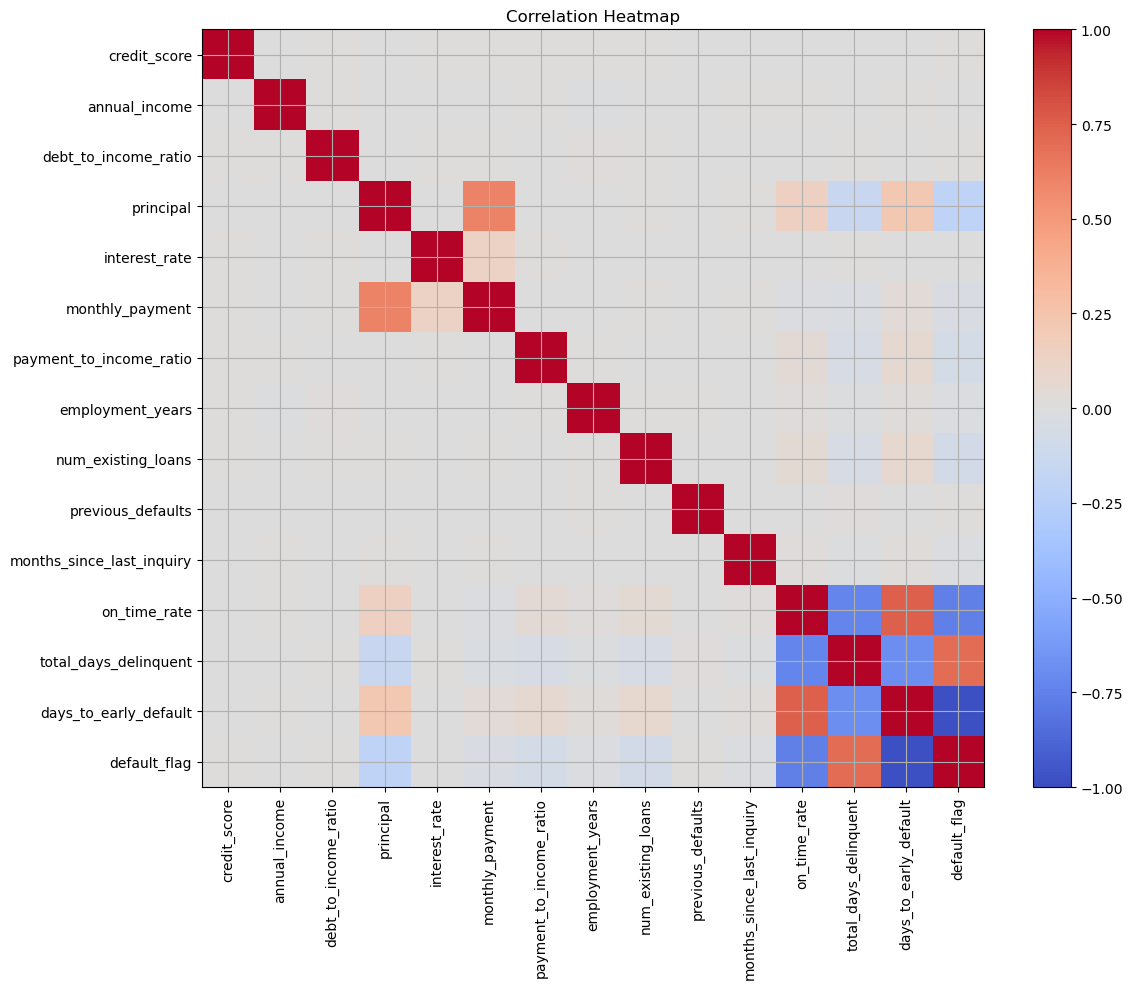


Top features correlated with default_flag:
days_to_early_default        0.979
on_time_rate                 0.755
total_days_delinquent        0.702
principal                    0.210
num_existing_loans           0.073
payment_to_income_ratio      0.065
monthly_payment              0.037
months_since_last_inquiry    0.021
employment_years             0.017
previous_defaults            0.008
annual_income                0.004
debt_to_income_ratio         0.004
credit_score                 0.001
interest_rate                0.000


In [59]:
# Correlation heatmap
corr_cols = [
    "credit_score", "annual_income", "debt_to_income_ratio",
    "principal", "interest_rate", "monthly_payment",
    "payment_to_income_ratio", "employment_years", "num_existing_loans",
    "previous_defaults", "months_since_last_inquiry",
    "on_time_rate", "total_days_delinquent",
    "days_to_early_default", "default_flag",
]

corr_matrix = train_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90)
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Highlight top correlations with default_flag
top_corr = corr_matrix["default_flag"].drop("default_flag").abs().sort_values(ascending=False)
print("\nTop features correlated with default_flag:")
print(top_corr.round(3).to_string())

In [60]:
# Save EDA artefacts
eda_dir = os.path.join(DATA_DIR, "eda_outputs")
os.makedirs(eda_dir, exist_ok=True)

summary_stats.to_csv(os.path.join(eda_dir, "summary_stats.csv"))
group_means.to_csv(os.path.join(eda_dir, "default_group_means.csv"))
corr_matrix.to_csv(os.path.join(eda_dir, "correlation_matrix.csv"))

print(f"EDA outputs saved to {eda_dir}")

EDA outputs saved to /Users/apple/Library/CloudStorage/OneDrive-MissouriStateUniversity/AITCC/赛/Analyze/Loan/eda_outputs


## 8. Train Models

We train three model families and compare them on the held-out validation set.
All models predict both regression (`days_to_early_default`) and classification
(`default_flag`).

**Statsmodels Logit** is used first for interpretability — it gives coefficients,
standard errors, and p-values. Then we compare sklearn Logistic + Linear,
Random Forest, and XGBoost on validation metrics.

In [61]:
# ── Statsmodels diagnostic Logit (interpretability) ──────────────────────────
# Reuses feature_cols but filters out constant columns first.
# has_payment_history == 1 for every row in this dataset, so it is perfectly
# collinear with sm.add_constant()'s intercept term → singular Hessian.
# sklearn models are unaffected (they don't invert the Hessian directly).
sm_cols = [c for c in feature_cols
           if X_tr[c].nunique() > 1]   # drop zero-variance columns

sm_scaler   = StandardScaler()
X_sm_scaled = sm_scaler.fit_transform(X_tr[sm_cols])
X_train_sm  = sm.add_constant(X_sm_scaled)

logit_model = sm.Logit(y_tr_cls, X_train_sm)
result      = logit_model.fit(maxiter=300, disp=False)
print(result.summary2(float_format="%.4f"))

                          Results: Logit
Model:               Logit            Method:           MLE       
Dependent Variable:  default_flag     Pseudo R-squared: 0.765     
Date:                2026-05-27 14:16 AIC:              22372.6096
No. Observations:    100799           BIC:              22534.4646
Df Model:            16               Log-Likelihood:   -11169.   
Df Residuals:        100782           LL-Null:          -47434.   
Converged:           0.0000           LLR p-value:      0.0000    
No. Iterations:      300.0000         Scale:            1.0000    
------------------------------------------------------------------
       Coef.    Std.Err.     z     P>|z|     [0.025       0.975]  
------------------------------------------------------------------
const 15.6628 128886.4642   0.0001 0.9999 -252597.1651 252628.4907
x1    -0.5075      0.0299 -16.9510 0.0000      -0.5661     -0.4488
x2     0.0339      0.0199   1.7010 0.0889      -0.0052      0.0729
x3    -1.0475      0.

In [62]:
# ── Baseline: Linear Regression + Logistic Regression ──────────────────────
model_scaler = StandardScaler()
X_tr_s  = model_scaler.fit_transform(X_tr)
X_val_s = model_scaler.transform(X_val)
X_eval_s = model_scaler.transform(X_eval)

reg_model = LinearRegression()
reg_model.fit(X_tr_s, y_tr_reg)
val_pred_reg_lr = reg_model.predict(X_val_s)

cls_model = LogisticRegression(max_iter=1000, random_state=42)
cls_model.fit(X_tr_s, y_tr_cls)
val_proba_cls_lr = cls_model.predict_proba(X_val_s)[:, 1]

lr_rmse = np.sqrt(mean_squared_error(y_val_reg, val_pred_reg_lr))
lr_r2   = r2_score(y_val_reg, val_pred_reg_lr)
lr_auc  = roc_auc_score(y_val_cls, val_proba_cls_lr)
print(f"Logistic + Linear  |  Val AUC: {lr_auc:.4f}  |  Val RMSE: {lr_rmse:.1f}  |  Val R²: {lr_r2:.4f}")

Logistic + Linear  |  Val AUC: 0.9650  |  Val RMSE: 116.4  |  Val R²: 0.6163


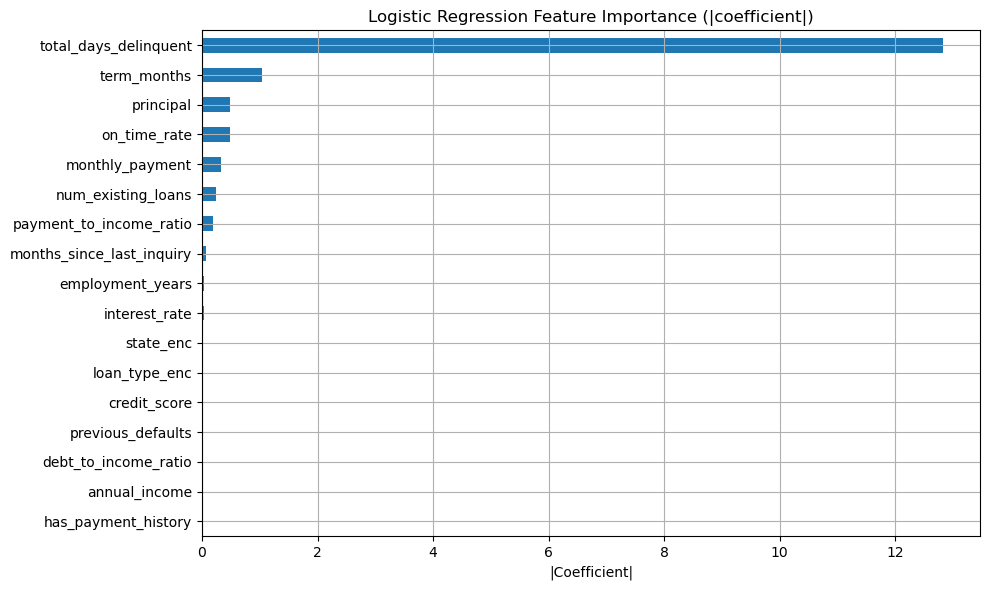

total_days_delinquent        12.8276
term_months                   1.0462
principal                     0.4867
on_time_rate                  0.4849
monthly_payment               0.3370
num_existing_loans            0.2462
payment_to_income_ratio       0.1825
months_since_last_inquiry     0.0743
employment_years              0.0424
interest_rate                 0.0357
state_enc                     0.0127
loan_type_enc                 0.0093
credit_score                  0.0086
previous_defaults             0.0085
debt_to_income_ratio          0.0084
annual_income                 0.0043
has_payment_history           0.0000


In [63]:
# ── P1.5: Feature Importance — Logistic Regression ─────────────────────────
importance_lr = pd.Series(
    np.abs(cls_model.coef_[0]), index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance_lr.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Logistic Regression Feature Importance (|coefficient|)")
plt.xlabel("|Coefficient|")
plt.tight_layout()
plt.show()
print(importance_lr.round(4).to_string())

Random Forest      |  Val AUC: 0.9633  |  Val RMSE: 87.6  |  Val R²: 0.7825


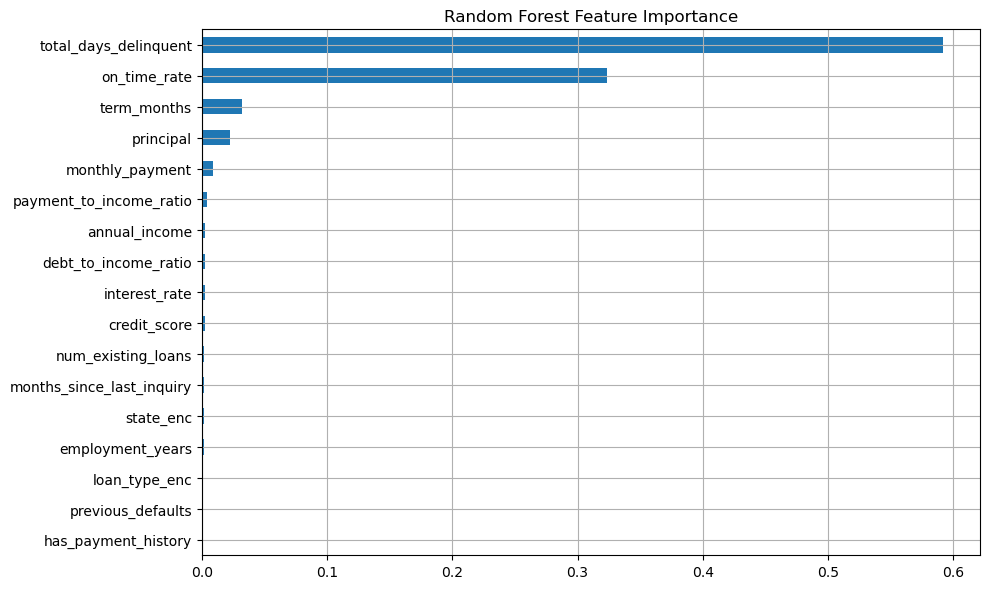

In [64]:
# ── Random Forest ──────────────────────────────────────────────────────────
rf_cls = RandomForestClassifier(n_estimators=200, max_depth=10,
                                 random_state=42, n_jobs=-1)
rf_cls.fit(X_tr, y_tr_cls)
val_proba_cls_rf = rf_cls.predict_proba(X_val)[:, 1]

rf_reg = RandomForestRegressor(n_estimators=200, max_depth=10,
                                random_state=42, n_jobs=-1)
rf_reg.fit(X_tr, y_tr_reg)
val_pred_reg_rf = rf_reg.predict(X_val)

rf_rmse = np.sqrt(mean_squared_error(y_val_reg, val_pred_reg_rf))
rf_r2   = r2_score(y_val_reg, val_pred_reg_rf)
rf_auc  = roc_auc_score(y_val_cls, val_proba_cls_rf)
print(f"Random Forest      |  Val AUC: {rf_auc:.4f}  |  Val RMSE: {rf_rmse:.1f}  |  Val R²: {rf_r2:.4f}")

# Feature importances (tree-based)
importance_rf = pd.Series(rf_cls.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importance_rf.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [65]:
# ── XGBoost ────────────────────────────────────────────────────────────────
if HAS_XGB:
    xgb_cls = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                             random_state=42, eval_metric="logloss", verbosity=0)
    xgb_cls.fit(X_tr, y_tr_cls)
    val_proba_cls_xgb = xgb_cls.predict_proba(X_val)[:, 1]

    xgb_reg = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05,
                            random_state=42, verbosity=0)
    xgb_reg.fit(X_tr, y_tr_reg)
    val_pred_reg_xgb = xgb_reg.predict(X_val)

    xgb_rmse = np.sqrt(mean_squared_error(y_val_reg, val_pred_reg_xgb))
    xgb_r2   = r2_score(y_val_reg, val_pred_reg_xgb)
    xgb_auc  = roc_auc_score(y_val_cls, val_proba_cls_xgb)
    print(f"XGBoost            |  Val AUC: {xgb_auc:.4f}  |  Val RMSE: {xgb_rmse:.1f}  |  Val R²: {xgb_r2:.4f}")
else:
    xgb_auc = xgb_rmse = xgb_r2 = None
    print("XGBoost not available — install with: pip install xgboost")

XGBoost not available — install with: pip install xgboost


In [66]:
# ── Model Comparison Table ─────────────────────────────────────────────────
rows = [
    {"Model": "Logistic + Linear (baseline)", "Val AUC": lr_auc, "Val RMSE": lr_rmse, "Val R²": lr_r2},
    {"Model": "Random Forest",                "Val AUC": rf_auc, "Val RMSE": rf_rmse, "Val R²": rf_r2},
]
if HAS_XGB:
    rows.append({"Model": "XGBoost", "Val AUC": xgb_auc, "Val RMSE": xgb_rmse, "Val R²": xgb_r2})

comparison = pd.DataFrame(rows).set_index("Model")
print("\n=== Validation Metrics ===")
print(comparison.round(4).to_string())

# Cross-check: do LR and RF agree on top features?
print("\n=== Feature Ranking Comparison (top 5) ===")
compare_df = pd.DataFrame({
    "LR |coef|": importance_lr,
    "RF importance": importance_rf,
})
compare_df["LR rank"] = importance_lr.rank(ascending=False).astype(int)
compare_df["RF rank"] = importance_rf.rank(ascending=False).astype(int)
print(compare_df.sort_values("LR rank").head(10).to_string())


=== Validation Metrics ===
                              Val AUC  Val RMSE  Val R²
Model                                                  
Logistic + Linear (baseline)   0.9650  116.3943  0.6163
Random Forest                  0.9633   87.6203  0.7825

=== Feature Ranking Comparison (top 5) ===
                           LR |coef|  RF importance  LR rank  RF rank
total_days_delinquent      12.827597       0.591883        1        1
term_months                 1.046199       0.032032        2        3
principal                   0.486736       0.022304        3        4
on_time_rate                0.484931       0.323878        4        2
monthly_payment             0.336998       0.008779        5        5
num_existing_loans          0.246234       0.002013        6       11
payment_to_income_ratio     0.182540       0.003630        7        6
months_since_last_inquiry   0.074268       0.001753        8       12
employment_years            0.042362       0.001658        9       14
inte

## 9. Generate Submission

Use the best-performing model (by validation AUC) to generate final predictions on the
held-out eval set.

In [67]:
# Pick best classifier and regressor by validation metric
models_cls = {"Logistic": (cls_model, X_eval_s, val_proba_cls_lr),
              "Random Forest": (rf_cls, X_eval, val_proba_cls_rf)}
models_reg = {"Linear": (reg_model, X_eval_s, val_pred_reg_lr),
              "Random Forest": (rf_reg, X_eval, val_pred_reg_rf)}

aucs = {"Logistic": lr_auc, "Random Forest": rf_auc}
rmses = {"Linear": lr_rmse, "Random Forest": rf_rmse}

if HAS_XGB:
    models_cls["XGBoost"] = (xgb_cls, X_eval, val_proba_cls_xgb)
    models_reg["XGBoost"] = (xgb_reg, X_eval, val_pred_reg_xgb)
    aucs["XGBoost"]  = xgb_auc
    rmses["XGBoost"] = xgb_rmse

best_cls_name = max(aucs, key=aucs.get)
best_reg_name = min(rmses, key=rmses.get)

best_cls_model, best_cls_X, _ = models_cls[best_cls_name]
best_reg_model, best_reg_X, _ = models_reg[best_reg_name]

print(f"Best classifier : {best_cls_name}  (Val AUC  {aucs[best_cls_name]:.4f})")
print(f"Best regressor  : {best_reg_name}  (Val RMSE {rmses[best_reg_name]:.1f})")

eval_pred_proba = best_cls_model.predict_proba(best_cls_X)[:, 1]
eval_pred_flag  = (eval_pred_proba >= 0.5).astype(int)

eval_pred_days  = np.round(best_reg_model.predict(best_reg_X)).astype(int)
eval_pred_days  = np.clip(eval_pred_days, 1, 3650)

submission = pd.DataFrame({
    "loan_id":                    eval_df["loan_id"],
    "predicted_days_to_default":  eval_pred_days,
    "predicted_default_flag":     eval_pred_flag,
    "predicted_default_proba":    eval_pred_proba,   # kept locally for scoring
})

sub_path = os.path.join(DATA_DIR, "submission.csv")
submission[["loan_id", "predicted_days_to_default", "predicted_default_flag"]].to_csv(
    sub_path, index=False)

print(f"\nSubmission written: {len(submission):,} rows → {sub_path}")
display(submission.head())

Best classifier : Logistic  (Val AUC  0.9650)
Best regressor  : Random Forest  (Val RMSE 87.6)

Submission written: 54,001 rows → /Users/apple/Library/CloudStorage/OneDrive-MissouriStateUniversity/AITCC/赛/Analyze/Loan/submission.csv


,loan_id,predicted_days_to_default,predicted_default_flag,predicted_default_proba
0,L89731-948612,1085,0,0.017746
1,L88609-534794,1089,0,0.021378
2,L56054-840867,1086,0,0.022081
3,L20994-783228,1094,0,0.005810
4,L96822-683296,1089,0,0.020399


## 10. Score Against Answer Key

In [68]:
scored = submission.merge(answer_key, on="loan_id", how="inner")

y_true_reg  = scored["days_to_early_default"].values
y_pred_reg  = scored["predicted_days_to_default"].values.astype(float)
y_true_cls  = scored["default_flag"].values
y_pred_cls  = scored["predicted_default_flag"].values
y_pred_proba = scored["predicted_default_proba"].values

rmse    = np.sqrt(mean_squared_error(y_true_reg, y_pred_reg))
mae     = mean_absolute_error(y_true_reg, y_pred_reg)
r2      = r2_score(y_true_reg, y_pred_reg)
auc_roc = roc_auc_score(y_true_cls, y_pred_proba)
f1      = f1_score(y_true_cls, y_pred_cls)

print("=== Regression (days_to_early_default) ===")
print(f"RMSE: {rmse:.1f} days")
print(f"MAE:  {mae:.1f} days")
print(f"R²:   {r2:.4f}")

print("\n=== Classification (default_flag) ===")
print(f"AUC-ROC: {auc_roc:.4f}")
print(f"F1:      {f1:.4f}")

print("\nCompare to benchmark.txt — did we beat it?")
with open(os.path.join(DATA_DIR, "benchmark.txt")) as f:
    print(f.read())

=== Regression (days_to_early_default) ===
RMSE: 87.0 days
MAE:  35.7 days
R²:   0.7867

=== Classification (default_flag) ===
AUC-ROC: 0.9629
F1:      0.9089

Compare to benchmark.txt — did we beat it?
--- Loan Default Benchmark ---
Train/Eval split: 70/30
Default rate: 18.0%

Regression (days_to_early_default):
  Linear Regression:
    RMSE: 167.6 days
    MAE:  126.5 days
    R2:   0.2082

  RF Regressor (n=100):
    RMSE: 167.3 days
    MAE:  112.9 days
    R2:   0.2112

Classification (default_flag):
  Logistic Regression:
    AUC-ROC: 0.8248
    F1:      0.3892

  RF Classifier (n=100):
    AUC-ROC: 0.8036
    F1:      0.3473


